In [1]:
from keras.models import Model

2026-06-16 16:58:36.598986: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781629116.769692      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781629116.822182      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781629117.242482      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781629117.242521      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781629117.242523      58 computation_placer.cc:177] computation placer alr

In [2]:
from keras.layers import *

In [3]:
x = Input(shape = (3, ))

In [4]:
hidden1 = Dense(128, activation = 'relu')(x)
hidden2 = Dense(64, activation = 'relu')(hidden1)

output1 = Dense(1, activation = 'linear')(hidden2)
output2 = Dense(1, activation = 'sigmoid')(hidden2)

I0000 00:00:1781629131.725651      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781629131.731541      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
model = Model(inputs = x, outputs = [output1, output2])

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,898 (34.76 KB)

 Trainable params: 8,898 (34.76 KB)

 Non-trainable params: 0 (0.00 B)

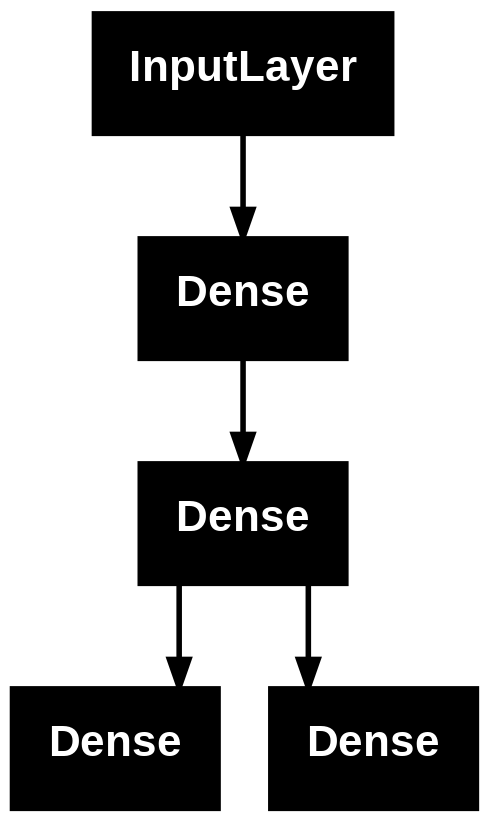

In [7]:
from keras.utils import plot_model
plot_model(model)

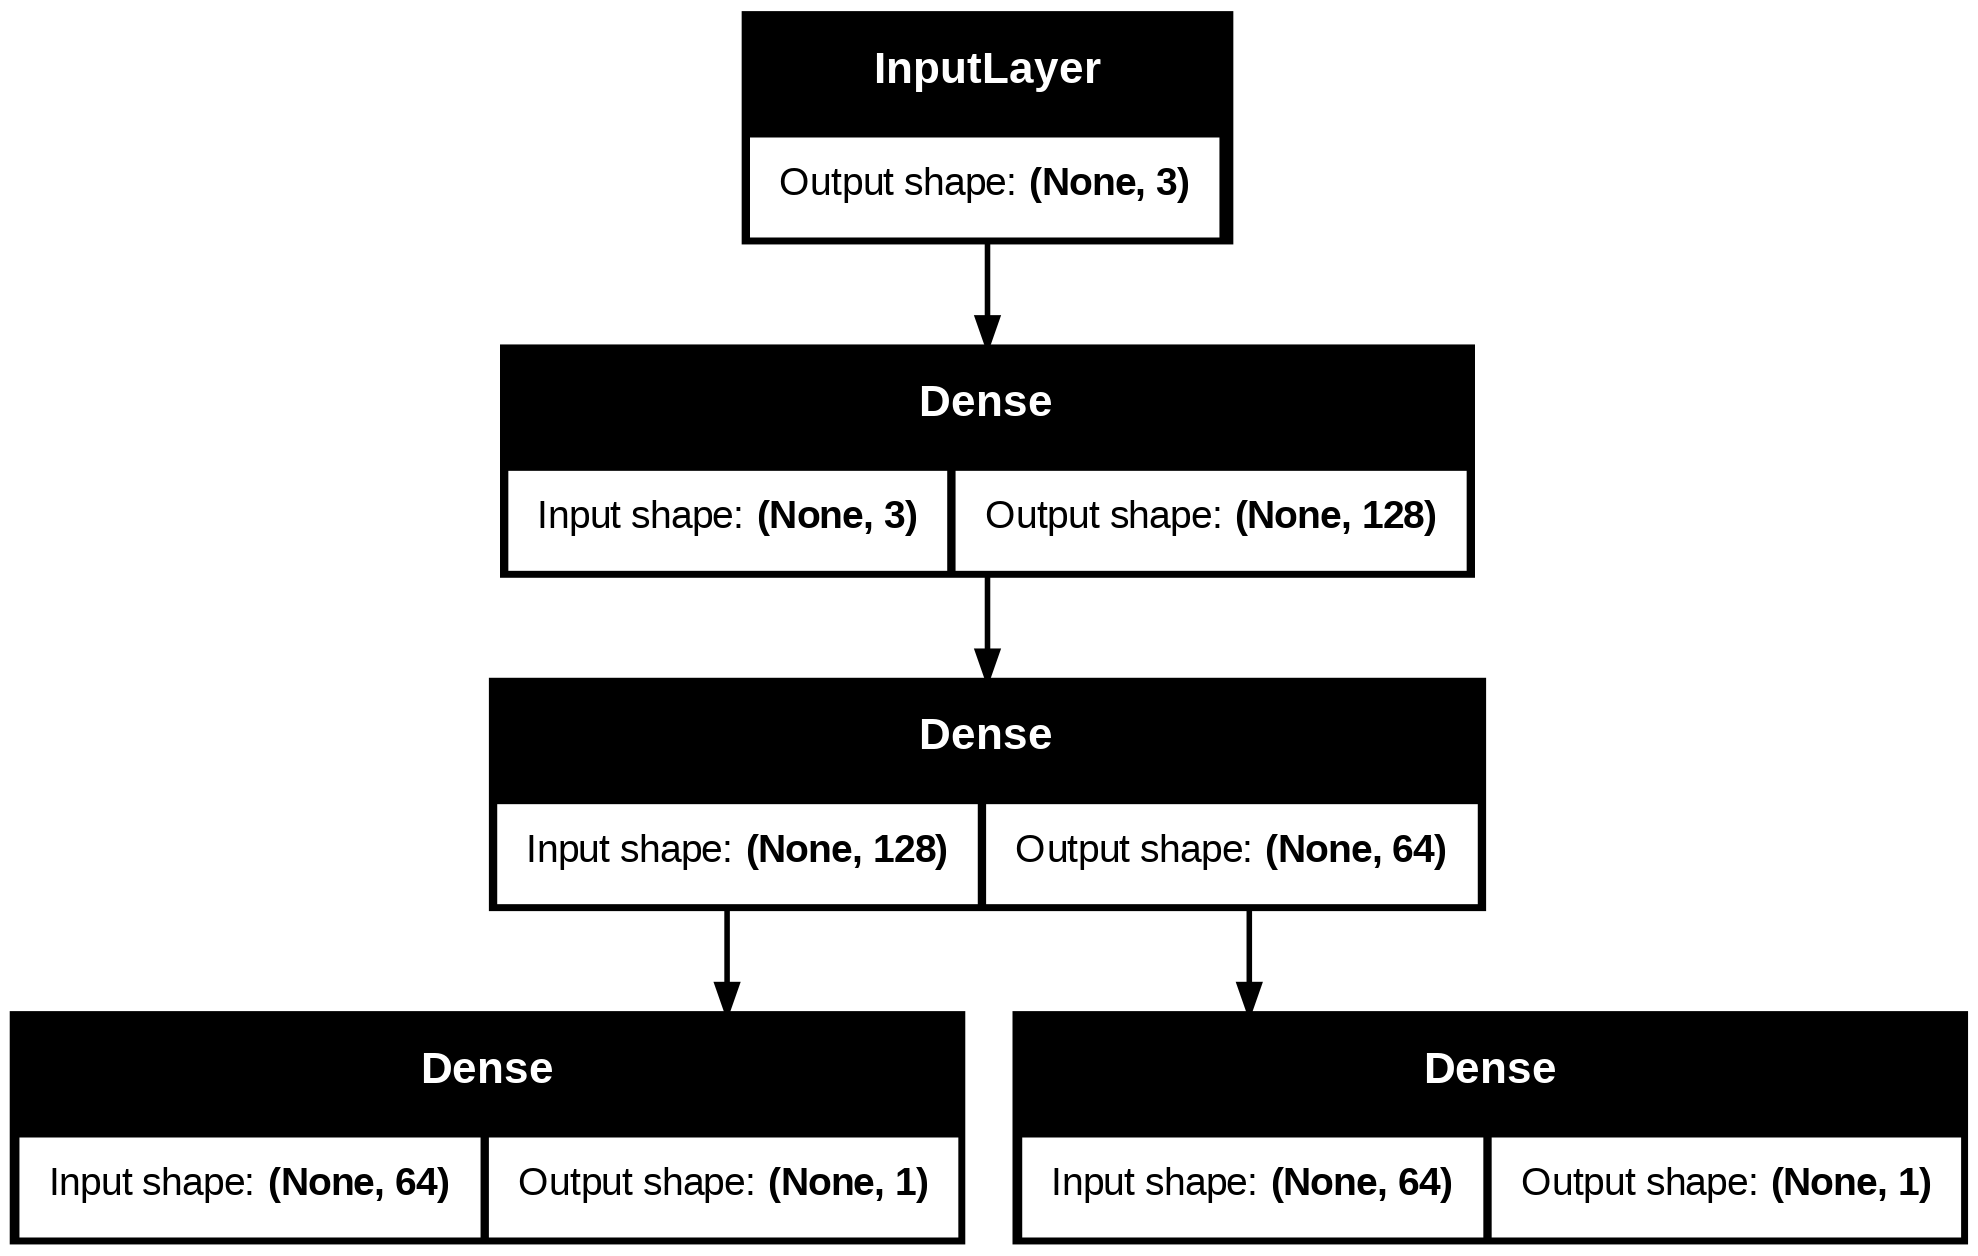

In [8]:
from keras.utils import plot_model
plot_model(model, show_shapes = True)

# Semi-Complex Architecture

In [9]:
from keras.layers import *
from keras.models import Model

In [10]:
# define two sets of inputs
inputA = Input(shape = (32, ))
inputB = Input(shape = (128, ))

In [11]:
# the first branch operates on the first input
x = Dense(8, activation = "relu")(inputA)
x1 = Dense(4, activation = "relu")(x)

In [12]:
# the second branch operates on the second input
y = Dense(64, activation = "relu")(inputB)
y1 = Dense(32, activation = "relu")(y)
y2 = Dense(4, activation = "relu")(y1)

In [13]:
# combine the output of the two branches
combined = concatenate([x1, y2])

In [14]:
# apply a FC layer and then a regression prediction on the
# combined outputs
z = Dense(2, activation = "relu")(combined)
z1 = Dense(1, activation = "linear")(z)

In [15]:
# our model will accept the inputs of the two branches and
# then output a single value
model = Model(inputs = [inputA, inputB], outputs = z)

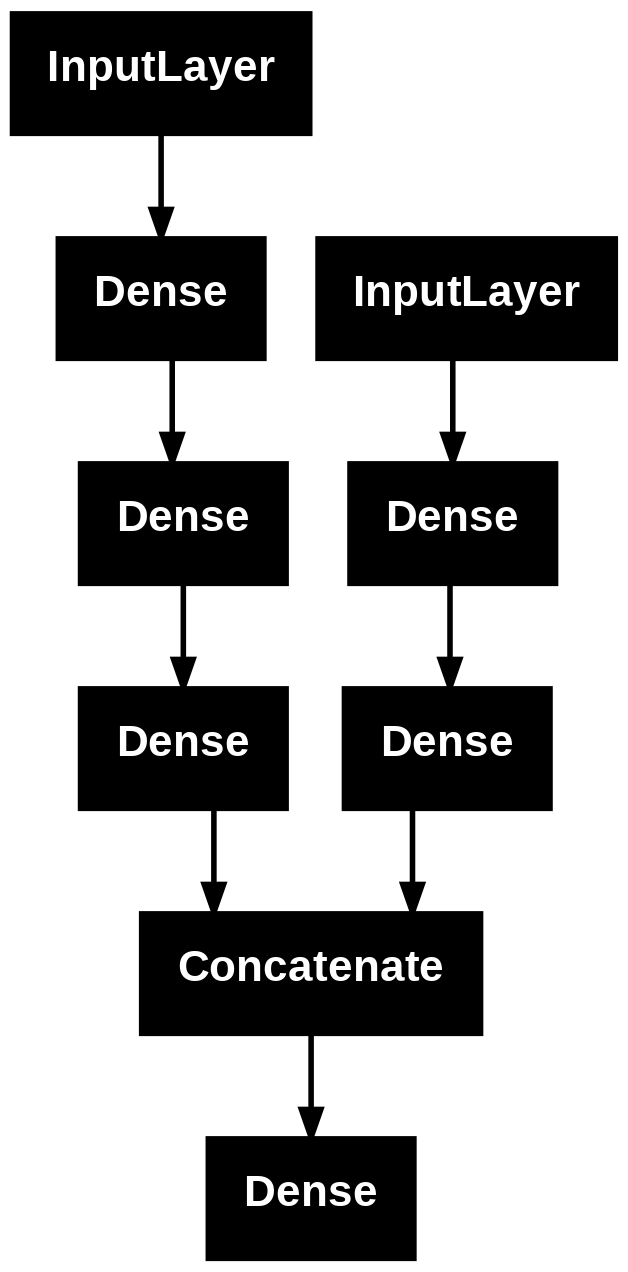

In [16]:
from keras.utils import plot_model
plot_model(model)

# Complex Architecture

In [17]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
folder_path = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'

In [19]:
age = []
gender = []
img_path = []
for file in os.listdir(folder_path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    img_path.append(file)

In [20]:
len(age)

23708

In [21]:
df = pd.DataFrame({'age':age, 'gender':gender, 'img':img_path})

In [22]:
df.shape

(23708, 3)

In [23]:
df.head()

,age,gender,img
0,26,0,26_0_2_20170104023102422.jpg.chip.jpg
1,22,1,22_1_1_20170112233644761.jpg.chip.jpg
2,21,1,21_1_3_20170105003215901.jpg.chip.jpg
3,28,0,28_0_0_20170117180555824.jpg.chip.jpg
4,17,1,17_1_4_20170103222931966.jpg.chip.jpg


In [24]:
train_df = df.sample(frac = 1, random_state = 0).iloc[:20000]
test_df = df.sample(frac = 1, random_state = 0).iloc[20000:]

In [25]:
train_df.shape

(20000, 3)

In [26]:
test_df.shape

(3708, 3)

In [27]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                  rotation_range = 30,
                                  width_shift_range = 0.2,
                                  height_shift_range = 0.2,
                                  shear_range = 0.2,
                                  zoom_range = 0.2,
                                  horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [28]:
# train_generator = train_datagen.flow_from_dataframe(train_df,
#                                                    directory = folder_path,
#                                                    x_col = 'img',
#                                                    y_col = ['age', 'gender'],
#                                                    target_size = (200, 200),
#                                                    class_mode = 'multi_output')

# test_generator = test_datagen.flow_from_dataframe(test_df,
#                                                   directory = folder_path,
#                                                   x_col = 'img',
#                                                   y_col = ['age', 'gender'],
#                                                   target_size = (200, 200),
#                                                   class_mode = 'multi_output')

In [29]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                   directory=folder_path,
                                                   x_col='img',
                                                   y_col=['age', 'gender'],
                                                   target_size=(200, 200),
                                                   class_mode='raw')

test_generator = test_datagen.flow_from_dataframe(test_df,
                                                  directory=folder_path,
                                                  x_col='img',
                                                  y_col=['age', 'gender'],
                                                  target_size=(200, 200),
                                                  class_mode='raw')

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [30]:
from keras.applications.vgg16 import VGG16
from keras.layers import *
from keras.models import Model

In [31]:
vggnet = VGG16(include_top = False, input_shape = (200, 200, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [32]:
vggnet.trainable = False

output = vggnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512, activation = 'relu')(flatten)
dense2 = Dense(512, activation = 'relu')(flatten)

dense3 = Dense(512, activation = 'relu')(dense1)
dense4 = Dense(512, activation = 'relu')(dense2)

output1 = Dense(1, activation = 'linear', name = 'age')(dense3)
output2 = Dense(1, activation = 'sigmoid', name = 'gender')(dense4)

In [33]:
model = Model(inputs = vggnet.input, outputs = [output1, output2])

In [34]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer_3[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 34,116,418 (130.14 MB)

 Trainable params: 19,401,730 (74.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

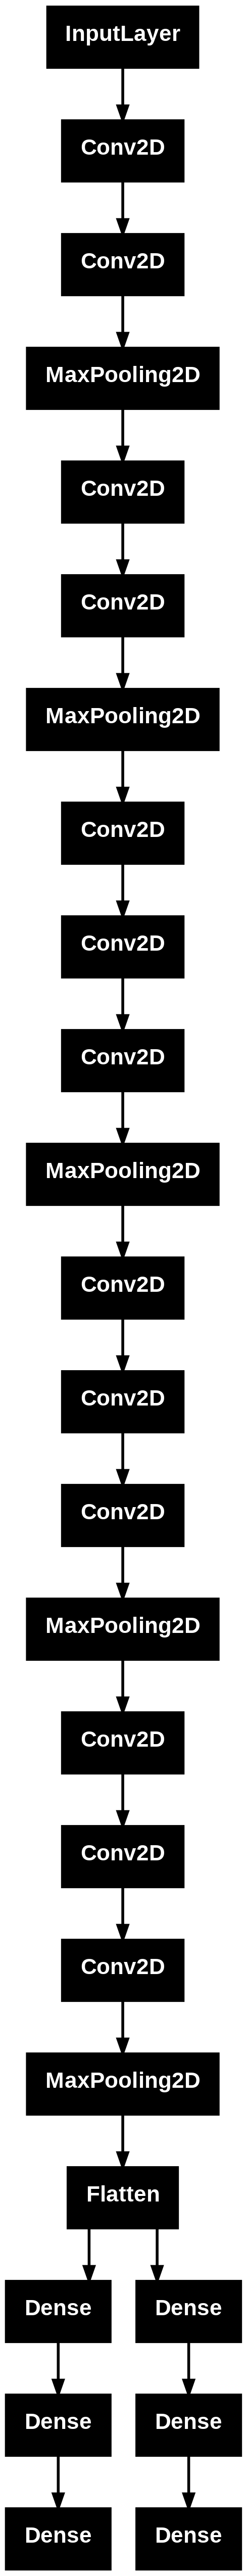

In [35]:
from keras.utils import plot_model
plot_model(model)

In [36]:
# model.compile(optimizer = 'adam', loss = {'age' : 'mae', 'gender' : 'binary_crossentropy'}, metrics = {'age' : 'mae', 'gender' : 'accuracy'}, loss_weights = {'age' : 1, 'gender' : 99})

In [37]:
# model.fit(train_generator, batch_size = 32, epochs = 10, validation_data = test_generator)
# model.fit(train_generator, epochs=10, validation_data=test_generator)

In [38]:
model.compile(optimizer='adam', 
              loss={'age': 'mae', 'gender': 'binary_crossentropy'}, 
              metrics={'age': 'mae', 'gender': 'accuracy'}, 
              loss_weights={'age': 1, 'gender': 99},
              run_eagerly=True)

In [39]:
import numpy as np

def custom_generator(gen):
    for X, y in gen:
        yield X, {'age': y[:, 0], 'gender': y[:, 1]}

model.fit(custom_generator(train_generator),
          epochs=10,
          steps_per_epoch=len(train_generator),
          validation_data=custom_generator(test_generator),
          validation_steps=len(test_generator))

Epoch 1/10


I0000 00:00:1781629184.168885      58 cuda_dnn.cc:529] Loaded cuDNN version 91002


625/625 ━━━━━━━━━━━━━━━━━━━━ 371s 577ms/step - age_loss: 10.9764 - age_mae: 10.9764 - gender_accuracy: 0.7426 - gender_loss: 0.5216 - loss: 62.6180 - val_age_loss: 9.0130 - val_age_mae: 9.0130 - val_gender_accuracy: 0.8376 - val_gender_loss: 0.3663 - val_loss: 45.2736
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 360s 577ms/step - age_loss: 9.4268 - age_mae: 9.4268 - gender_accuracy: 0.7882 - gender_loss: 0.4429 - loss: 53.2776 - val_age_loss: 8.0419 - val_age_mae: 8.0419 - val_gender_accuracy: 0.8176 - val_gender_loss: 0.3942 - val_loss: 47.0672
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 361s 578ms/step - age_loss: 9.0297 - age_mae: 9.0297 - gender_accuracy: 0.8033 - gender_loss: 0.4186 - loss: 50.4700 - val_age_loss: 8.0696 - val_age_mae: 8.0696 - val_gender_accuracy: 0.8561 - val_gender_loss: 0.3222 - val_loss: 39.9641
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 360s 577ms/step - age_loss: 8.8366 - age_mae: 8.8366 - gender_accuracy: 0.8122 - gender_loss: 0.4013 - loss: 48.5627 - val_age_loss: 8.